# Quickstart: Brightness Temperature

Simulating the broadband brightness temperature for various surface temperatures. 

In [1]:
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

config_path = Path('config/velox.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 24

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04T23:00:00', periods=N_timesteps, freq='s'),
        'latitude' : ('time', [51.3406321] * N_timesteps),
        'longitude' : ('time', [12.3747329] * N_timesteps),
        'altitude' : ('altitude', [0, 1, 10, 100]),
    },
    data_vars={
        'surface_temperature' : ('time', np.linspace(300, 300, N_timesteps)),
        'albedo' : ('time', np.linspace(0, 1, N_timesteps)),
    }
)

ds_sim = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    surface_temperature_var='surface_temperature',
    albedo_var='albedo',
    parameter_overrides={
        'output_quantity' : 'brightness',
    },
)

print("\nSimulation complete!")
print(f"Dataset variables: {list(ds_sim.data_vars.keys())}")
print(f"Dataset coordinates: {list(ds_sim.coords.keys())}")
print(f"Dataset shape: {ds_sim.dims}")


Simulation complete!
Dataset variables: ['eup', 'edn', 'edir']
Dataset coordinates: ['time', 'latitude', 'longitude', 'altitude']
Dataset shape: FrozenMappingWarningOnValuesAccess({'time': 24, 'altitude': 4})


## Albedo, Emissivity and Surface Temperature

Libradtran calculates the emissivity of the surface based on the albedo of the surface, if albedo = 0, the emissivity is 1, if albedo = 1, the emissivity is 0.

Text(0, 0.5, 'Brightness Temperature (K)')

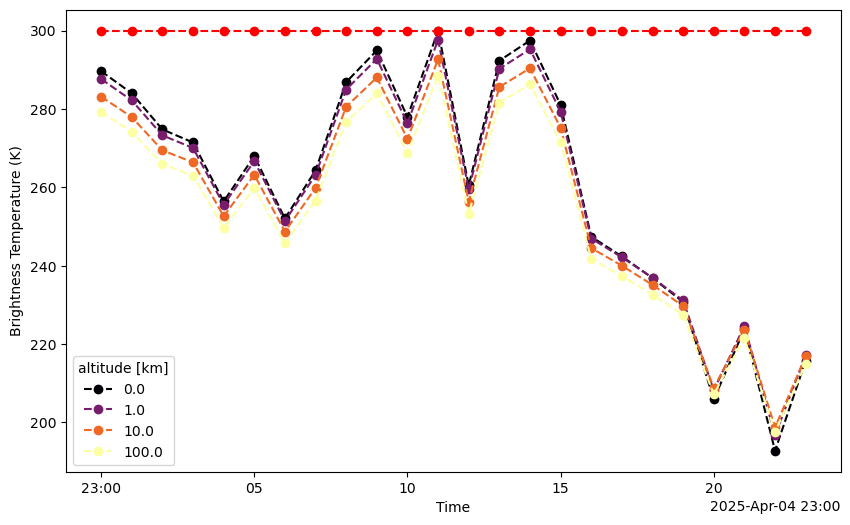

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))
# change prop cycle to inferno
ax.set_prop_cycle(color=plt.cm.inferno(np.linspace(0, 1, len(ds_sim.altitude))))


ds_sim.eup.plot(marker='o', linestyle='--', hue='altitude', label='simulated brightness temperature (up)')
ds.surface_temperature.plot(marker='o', linestyle='--', color='red', label='surface temperature')
plt.xlabel('Time')
plt.ylabel('Brightness Temperature (K)')
